[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Task 12.1

Frequency Response of FIR Filter
- a) analytical DTFT
- b) DFT
- c) zeropadded DFT
- d) DFT -> DTFT interpolation


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import diric
from numpy.fft import fft

In [2]:
h = np.array([1, 0, 1, 0, 17/4, 0, 17/4, 0, 1, 0, 1])
N = np.size(h)
k = np.arange(N)

## a) analytical DTFT

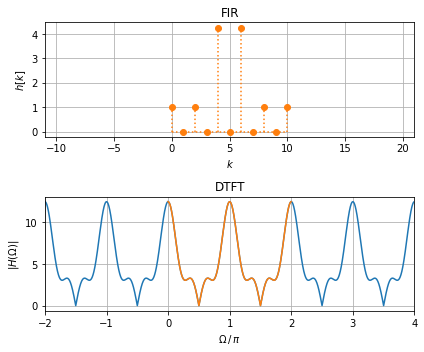

In [3]:
Ndtft = 2**10
dW = 2*np.pi / Ndtft
Wdtft = np.arange(Ndtft) * dW
Hdtft = (2*np.cos(5*Wdtft) + 2*np.cos(3*Wdtft) +
         17/2*np.cos(Wdtft)) * np.exp(-1j*5*Wdtft)

plt.figure(figsize=(6, 5), tight_layout=True)
plt.subplot(2, 1, 1)
plt.stem(k, h,
         use_line_collection=True,
         linefmt='C1:', markerfmt='C1o', basefmt='C1:')
plt.xlim(-N, 2*N-1)
plt.xlabel(r'$k$')
plt.ylabel(r'$h[k]$')
plt.title('FIR')
plt.grid(True)

plt.subplot(2, 1, 2)
for nu in range(-1, 2):
    plt.plot((Wdtft+nu*2*np.pi)/np.pi, np.abs(Hdtft), 'C0')
plt.plot(Wdtft/np.pi, np.abs(Hdtft), 'C1')
plt.xlim(-2, 4)
plt.xlabel(r'$\Omega \,/\, \pi$')
plt.ylabel(r'$|H(\Omega)|$')
plt.title('DTFT')
plt.grid(True)

plt.savefig('DTFT_6337B75DF2.pdf')

## b) DFT

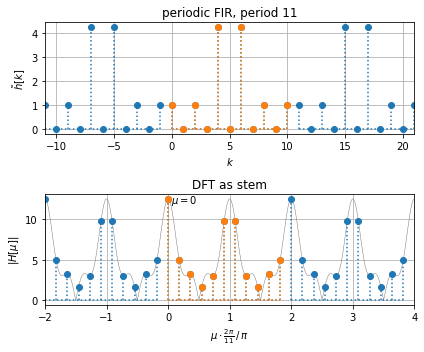

In [4]:
Hdft = fft(h)
mu = np.arange(N)
Wdft = mu * 2*np.pi/N

plt.figure(figsize=(6, 5), tight_layout=True)
plt.subplot(2, 1, 1)
for kk in range(-1, 2):
    plt.stem(k + kk*N, h,
             use_line_collection=True,
             linefmt='C0:', markerfmt='C0o', basefmt='C0:')
plt.stem(k, h,
         use_line_collection=True,
         linefmt='C1:', markerfmt='C1o', basefmt='C1:')
plt.xlim(-N, 2*N-1)
plt.xlabel(r'$k$')
plt.ylabel(r'$\tilde{h}[k]$')
plt.title('periodic FIR, period 11')
plt.grid(True)

plt.subplot(2, 1, 2)
for nu in range(-1, 2):
    plt.plot((Wdtft+nu*2*np.pi)/np.pi, np.abs(Hdtft), 'C7', lw=0.5)
    plt.stem((Wdft + nu*2*np.pi)/np.pi, np.abs(Hdft),
             use_line_collection=True,
             linefmt='C0:', markerfmt='C0o', basefmt='C0:')
plt.stem(Wdft/np.pi, np.abs(Hdft),
         use_line_collection=True,
         linefmt='C1:', markerfmt='C1o', basefmt='C1:')
plt.text(0.05, 12, r'$\mu=0$')
plt.xlim(-2, 4)
plt.xlabel(r'$\mu \cdot \frac{2\pi}{11} \,/\, \pi$')
plt.ylabel(r'$|H[\mu]|$')
plt.title('DFT as stem')
plt.grid(True)

plt.savefig('DFT_6337B75DF2.pdf')

## c) Zeropadded DFT, Nz=16

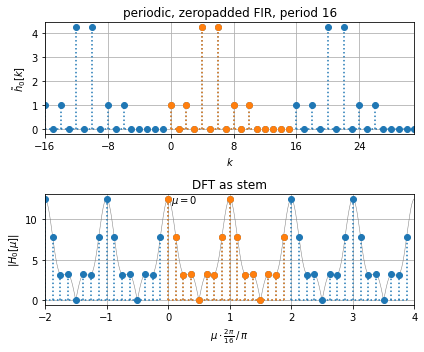

In [5]:
Nz = 16
hz = np.zeros(Nz)
hz[0:N] = h[:]
kz = np.arange(Nz)

Hdftz = fft(hz)
mu = np.arange(Nz)
Wdftz = mu * 2*np.pi/Nz

plt.figure(figsize=(6, 5), tight_layout=True)
plt.subplot(2, 1, 1)
for kk in range(-1, 2):
    plt.stem(kz + kk*Nz, hz,
             use_line_collection=True,
             linefmt='C0:', markerfmt='C0o', basefmt='C0:')
plt.stem(kz, hz,
         use_line_collection=True,
         linefmt='C1:', markerfmt='C1o', basefmt='C1:')
plt.xlim(-Nz, 2*Nz-1)
plt.xticks(np.arange(-Nz, 2*Nz, 8))
plt.xlabel(r'$k$')
plt.ylabel(r'$\tilde{h}_0[k]$')
plt.title('periodic, zeropadded FIR, period 16')
plt.grid(True)

plt.subplot(2, 1, 2)
for nu in range(-1, 2):
    plt.plot((Wdtft+nu*2*np.pi)/np.pi, np.abs(Hdtft), 'C7', lw=0.5)
    plt.stem((Wdftz + nu*2*np.pi)/np.pi, np.abs(Hdftz),
             use_line_collection=True,
             linefmt='C0:', markerfmt='C0o', basefmt='C0:')
plt.stem(Wdftz/np.pi, np.abs(Hdftz),
         use_line_collection=True,
         linefmt='C1:', markerfmt='C1o', basefmt='C1:')
plt.text(0.05, 12, r'$\mu=0$')
plt.xlim(-2, 4)
plt.xlabel(r'$\mu \cdot \frac{2\pi}{16} \,/\, \pi$')
plt.ylabel(r'$|H_0[\mu]|$')
plt.title('DFT as stem')
plt.grid(True)

plt.savefig('DFT_zeropad16_6337B75DF2.pdf')

## c) Zeropadded DFT, Nz=32

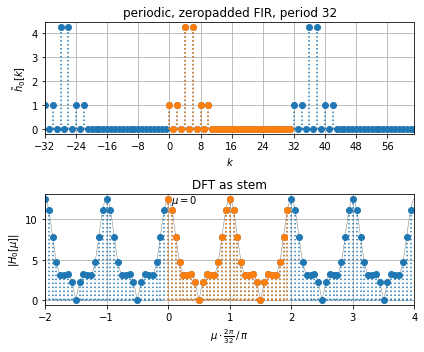

In [6]:
Nz = 32
hz = np.zeros(Nz)
hz[0:N] = h[:]
kz = np.arange(Nz)

Hdftz = fft(hz)
mu = np.arange(Nz)
Wdftz = mu * 2*np.pi/Nz

plt.figure(figsize=(6, 5), tight_layout=True)
plt.subplot(2, 1, 1)
for kk in range(-1, 2):
    plt.stem(kz + kk*Nz, hz,
             use_line_collection=True,
             linefmt='C0:', markerfmt='C0o', basefmt='C0:')
plt.stem(kz, hz,
         use_line_collection=True,
         linefmt='C1:', markerfmt='C1o', basefmt='C1:')
plt.xlim(-Nz, 2*Nz-1)
plt.xticks(np.arange(-Nz, 2*Nz, 8))
plt.xlabel(r'$k$')
plt.ylabel(r'$\tilde{h}_0[k]$')
plt.title('periodic, zeropadded FIR, period 32')
plt.grid(True)

plt.subplot(2, 1, 2)
for nu in range(-1, 2):
    plt.plot((Wdtft+nu*2*np.pi)/np.pi, np.abs(Hdtft), 'C7', lw=0.5)
    plt.stem((Wdftz + nu*2*np.pi)/np.pi, np.abs(Hdftz),
             use_line_collection=True,
             linefmt='C0:', markerfmt='C0o', basefmt='C0:')
plt.stem(Wdftz/np.pi, np.abs(Hdftz),
         use_line_collection=True,
         linefmt='C1:', markerfmt='C1o', basefmt='C1:')
plt.text(0.05, 12, r'$\mu=0$')
plt.xlim(-2, 4)
plt.xlabel(r'$\mu \cdot \frac{2\pi}{32} \,/\, \pi$')
plt.ylabel(r'$|H_0[\mu]|$')
plt.title('DFT as stem')
plt.grid(True)

plt.savefig('DFT_zeropad32_6337B75DF2.pdf')

In [7]:
def interpolate_dft2dtft(X, W):
    """DFT to DTFT interpolation.

    This is the reconstruction filter in frequency domain to get
    a finite length time sequence starting from k=0 out of a periodic sequence
    X...array containing DFT spectrum
    W...array with normalized digital frequencies
    typically W = np.arange(N) * 2*np.pi/N with desired N

    see e.g.
    Rabiner, Gold, 1975, Theory and Application of Digital Signal Processing
    Prentice Hall, eq. (2.142)

    """
    N = np.size(X)  # we estimate the DFT length from the DFT spectrum
    tmp_2piN = 2*np.pi/N
    tmp_N2 = (N-1)/2
    Xint = np.zeros_like(W, dtype='complex')
    for cW, vW in enumerate(W):  # counter, value
        for cX, vX in enumerate(X):
            W_tmp = vW - tmp_2piN * cX
            Xint[cW] += vX * diric(W_tmp, N) * np.exp(-1j*W_tmp*tmp_N2)
    return Xint


def interpolate_dft2dtft_rabiner_gold(X, W):
    N = np.size(X)
    tmp_2piN = 2*np.pi/N
    tmp_N2 = (N-1)/2
    Xint = np.zeros_like(W, dtype='complex')
    for cW, vW in enumerate(W):
        for cX, vX in enumerate(X):
            Xint[cW] += vX/N*np.exp(-1j*vW*tmp_N2)*np.sin(vW*N/2) / \
                np.sin(vW/2-np.pi*cX/N)/np.exp(+1j*np.pi*cX/N)
    return Xint

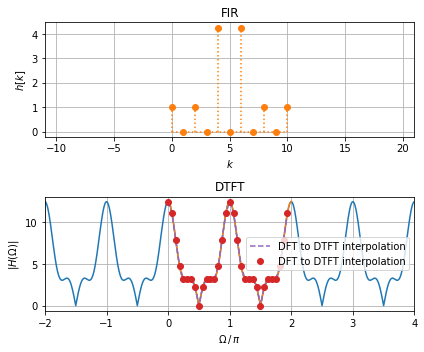

In [8]:
Nint = 2**5
Wint = np.arange(Nint) * 2*np.pi/Nint
Hint = interpolate_dft2dtft(Hdft, Wint)

plt.figure(figsize=(6, 5), tight_layout=True)
plt.subplot(2, 1, 1)
plt.stem(k, h,
         use_line_collection=True,
         linefmt='C1:', markerfmt='C1o', basefmt='C1:')
plt.xlim(-N, 2*N-1)
plt.xlabel(r'$k$')
plt.ylabel(r'$h[k]$')
plt.title('FIR')
plt.grid(True)

plt.subplot(2, 1, 2)
for nu in range(-1, 2):
    plt.plot((Wdtft+nu*2*np.pi)/np.pi, np.abs(Hdtft), 'C0')
plt.plot(Wdtft/np.pi, np.abs(Hdtft), 'C1')
plt.plot(Wint/np.pi, np.abs(Hint), 'C4--', label='DFT to DTFT interpolation')
plt.plot(Wint/np.pi, np.abs(Hint), 'C3o', label='DFT to DTFT interpolation')

plt.xlim(-2, 4)
plt.xlabel(r'$\Omega \,/\, \pi$')
plt.ylabel(r'$|H(\Omega)|$')
plt.title('DTFT')
plt.legend()
plt.grid(True)

plt.savefig('DFT2DTFT_6337B75DF2.pdf')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.